# Heart Disease Prediction - Gradient Boosting Training

**Dataset:** heart_disease.csv (1.5 lakh rows; target: 0=Absence, 1=Presence)

**Steps:**
1. Data Load
2. EDA (Shape, Missing, Basic stats, Target Distribution)
3. Correlation Analysis
4. Preprocessing
5. Train-Test Split (80/20)
6. Model Training (Gradient Boosting)
7. Test Prediction (y_pred, y_prob)
8. Accuracy & Evaluation (Confusion matrix)
9. ROC Curve
10. Best Threshold (Youden Index)
11. Save Model, Scaler, threshold.json

## Step 1: Data Load

In [1]:
import os
import pandas as pd
import numpy as np

# CSV path (change if your file is elsewhere)
DATASET_PATH = r"D:\DP\ml_training\heart_disease.csv"
REQUIRED_COLS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
ALIAS_MAP = {
    "chest_pain_type": "cp", "resting_bp": "trestbps", "serum_cholesterol": "chol",
    "fasting_blood_sugar": "fbs", "resting_ecg": "restecg", "max_heart_rate": "thalach",
    "exercise_induced_angina": "exang", "st_depression": "oldpeak",
    "num_major_vessels": "ca", "thalassemia": "thal",
}

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Run reduce_heart_dataset.py first to create {DATASET_PATH}.")

df = pd.read_csv(DATASET_PATH)
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
for src, dst in ALIAS_MAP.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src: dst})

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[REQUIRED_COLS].copy()
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 150000
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,57,1,2,120,177,0,0,132,0,1.2,2,0,3,0
1,41,1,4,132,274,0,2,122,0,0.0,1,0,3,1
2,63,1,4,140,239,0,2,145,1,2.2,2,1,7,1
3,47,1,4,140,197,0,2,147,1,1.6,2,1,7,1
4,50,0,3,140,298,0,0,152,0,0.0,1,0,3,0


## Step 2: EDA (Exploratory Data Analysis)

In [2]:
print("=" * 60)
print("SHAPE & INFO")
print("=" * 60)
print(df.shape)
df.info()

SHAPE & INFO
(150000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   age       150000 non-null  int64  
 1   sex       150000 non-null  int64  
 2   cp        150000 non-null  int64  
 3   trestbps  150000 non-null  int64  
 4   chol      150000 non-null  int64  
 5   fbs       150000 non-null  int64  
 6   restecg   150000 non-null  int64  
 7   thalach   150000 non-null  int64  
 8   exang     150000 non-null  int64  
 9   oldpeak   150000 non-null  float64
 10  slope     150000 non-null  int64  
 11  ca        150000 non-null  int64  
 12  thal      150000 non-null  int64  
 13  target    150000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 16.0 MB


In [3]:
print("MISSING VALUES")
print(df.isna().sum())
print("\nDESCRIPTIVE STATISTICS")
df.describe()

MISSING VALUES
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

DESCRIPTIVE STATISTICS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,54.139647,0.714513,3.309853,130.561353,245.153773,0.080413,0.982220,152.704067,0.274760,0.719230,1.454720,0.451627,4.621120,0.448140
std,8.253608,0.451647,0.853313,15.012090,33.744005,0.271933,0.998761,19.148155,0.446395,0.949778,0.544835,0.799415,1.950855,0.497305
min,29.000000,0.000000,1.000000,94.000000,130.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [4]:
print("TARGET DISTRIBUTION")
print(df["target"].value_counts())
print("\nTarget balance:")
print(df["target"].value_counts(normalize=True).round(4))

TARGET DISTRIBUTION
target
0    82779
1    67221
Name: count, dtype: int64

Target balance:
target
0    0.5519
1    0.4481
Name: proportion, dtype: float64


## Step 2d: Correlation Analysis

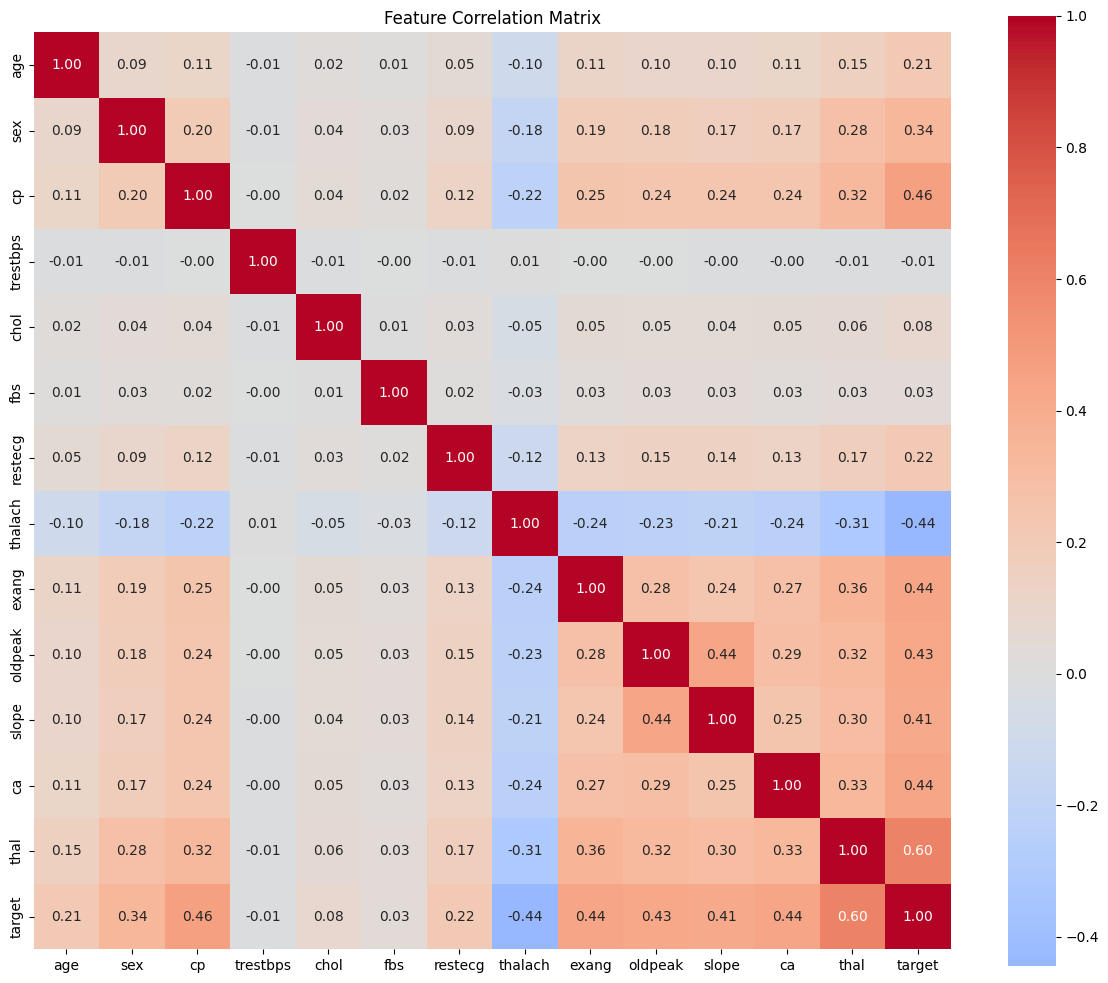

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 3: Preprocessing

In [6]:
processed = df.copy()

for col in REQUIRED_COLS:
    processed[col] = pd.to_numeric(processed[col], errors="coerce")

processed.fillna(processed.median(numeric_only=True), inplace=True)
processed["target"] = (processed["target"] > 0).astype(int)

print("Missing after cleaning:", processed.isna().sum().sum())
print("Target (binary):", processed["target"].value_counts().to_dict())
processed.head()

Missing after cleaning: 0
Target (binary): {0: 82779, 1: 67221}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,57,1,2,120,177,0,0,132,0,1.2,2,0,3,0
1,41,1,4,132,274,0,2,122,0,0.0,1,0,3,1
2,63,1,4,140,239,0,2,145,1,2.2,2,1,7,1
3,47,1,4,140,197,0,2,147,1,1.6,2,1,7,1
4,50,0,3,140,298,0,0,152,0,0.0,1,0,3,0


## Step 4: Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

FEATURE_ORDER = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
X = processed[FEATURE_ORDER]
y = processed["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target:", y_train.value_counts().to_dict())
print("Test target:", y_test.value_counts().to_dict())

Train shape: (120000, 13)
Test shape: (30000, 13)
Train target: {0: 66223, 1: 53777}
Test target: {0: 16556, 1: 13444}


## Step 5: Model Training (Gradient Boosting)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

base_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
model = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)
print("Gradient Boosting training completed.")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}
Gradient Boosting training completed.


## Step 6: Accuracy & Evaluation

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy, 4), f"({accuracy * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8882 (88.82%)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     16556
           1       0.88      0.87      0.87     13444

    accuracy                           0.89     30000
   macro avg       0.89      0.89      0.89     30000
weighted avg       0.89      0.89      0.89     30000

Confusion Matrix:
[[14981  1575]
 [ 1778 11666]]


## Step 7: ROC Curve

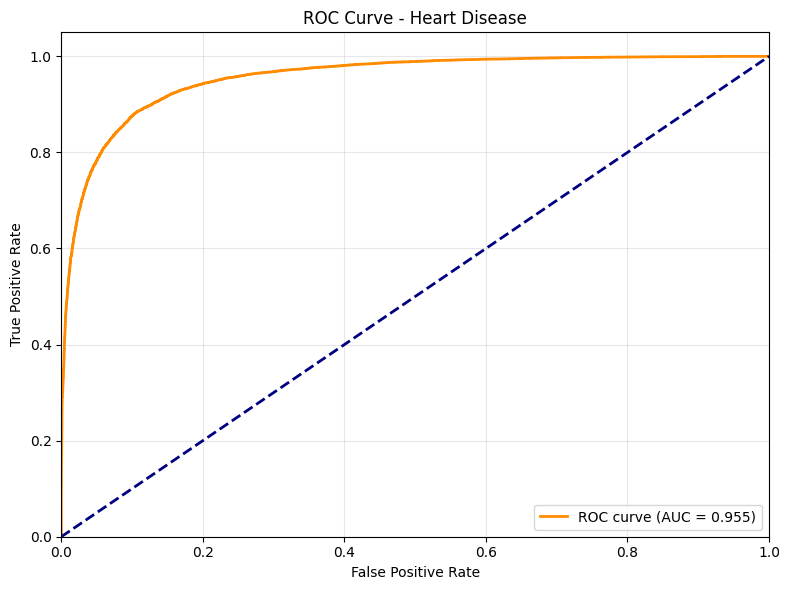

In [10]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Heart Disease')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Best Threshold (Youden Index)

In [11]:
# Youden Index: J = sensitivity + specificity - 1 = TPR - FPR
# Best threshold maximizes J
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
print(f"Best threshold (Youden Index): {best_threshold:.4f}")

Best threshold (Youden Index): 0.4485


## Step 9: Save Model, Scaler, threshold.json

In [12]:
import joblib
import json

os.makedirs("../backend/ml_models", exist_ok=True)
model_path = "../backend/ml_models/heart_disease_model.pkl"
scaler_path = "../backend/ml_models/heart_disease_scaler.pkl"
threshold_path = "../backend/ml_models/threshold.json"

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

thresh_data = {}
if os.path.exists(threshold_path):
    with open(threshold_path) as f:
        thresh_data = json.load(f)
thresh_data["heart_disease"] = float(best_threshold)
with open(threshold_path, "w") as f:
    json.dump(thresh_data, f, indent=2)

print("Saved:")
print(f"  Model: {model_path}")
print(f"  Scaler: {scaler_path}")
print(f"  Threshold: {threshold_path} (heart_disease={best_threshold:.4f})")
print(f"  Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

Saved:
  Model: ../backend/ml_models/heart_disease_model.pkl
  Scaler: ../backend/ml_models/heart_disease_scaler.pkl
  Threshold: ../backend/ml_models/threshold.json (heart_disease=0.4485)
  Test Accuracy: 0.8882 (88.82%)
